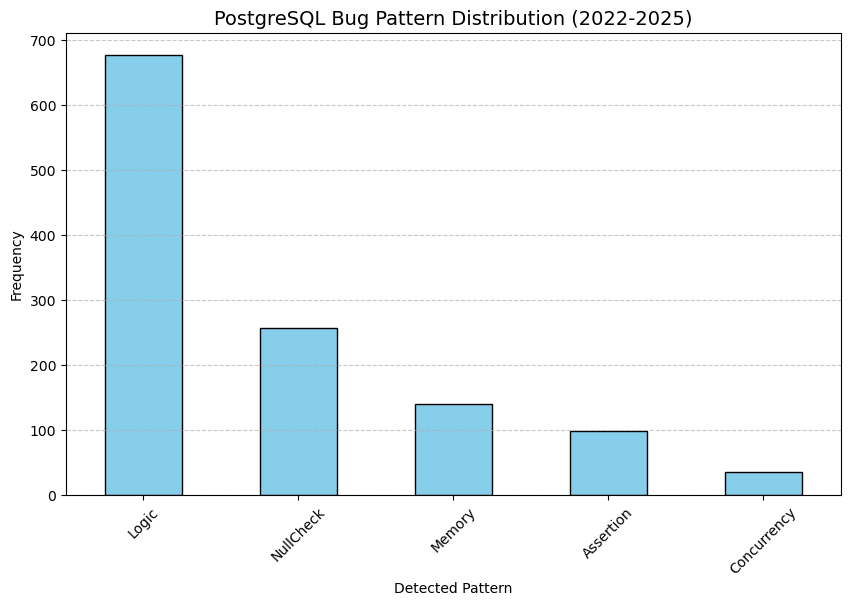

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取你刚刚生成的汇总表
df = pd.read_csv('static_pattern_summary.csv')

# 处理一个 Diff 属于多个模式的情况
patterns_series = df['patterns'].str.split(', ').explode()
counts = patterns_series.value_counts()

# 绘图
plt.figure(figsize=(10, 6))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('PostgreSQL Bug Pattern Distribution (2022-2025)', fontsize=14)
plt.ylabel('Frequency')
plt.xlabel('Detected Pattern')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('pattern_distribution.png', bbox_inches='tight')

In [8]:
import os
import re
from pycparser import c_parser, c_ast

# --- 配置区 ---
DIFF_DIR = 'static_analysis_diffs'
OUTPUT_REPORT = 'ast_logic_analysis_report.csv'

class ASTPatternVisitor(c_ast.NodeVisitor):
    """AST 访问器：专门抓取 If 条件和函数调用"""
    def __init__(self):
        self.results = []

    def visit_If(self, node):
        # 简单提取条件表达式的文本特征
        cond_str = self._node_to_str(node.cond)
        self.results.append(f"IF_CONDITION({cond_str})")
        self.generic_visit(node)

    def visit_FuncCall(self, node):
        if isinstance(node.name, c_ast.ID):
            self.results.append(f"CALL({node.name.name})")
        self.generic_visit(node)

    def _node_to_str(self, node):
        """将 AST 节点转换为简易字符串描述"""
        if isinstance(node, c_ast.BinaryOp):
            return f"{self._node_to_str(node.left)} {node.op} {self._node_to_str(node.right)}"
        elif isinstance(node, c_ast.ID): return node.name
        elif isinstance(node, c_ast.Constant): return node.value
        elif isinstance(node, c_ast.UnaryOp): return f"{node.op}{self._node_to_str(node.expr)}"
        return "expr"


def pre_process_pg_code(code):
    """
    清洗 PostgreSQL 源码片段，使其兼容 pycparser
    """
    # 1. 替换常用的 PG 宏为标准函数调用
    code = re.sub(r'\bAssert\(', 'dummy_assert(', code)
    code = re.sub(r'\bereport\(', 'dummy_ereport(', code)
    code = re.sub(r'\berrmsg\(', 'dummy_errmsg(', code)
    
    # 2. 移除 PG 特有的属性修饰符（这些常导致解析失败）
    code = re.sub(r'\bPG_USED_FOR_ASMS?\b', '', code)
    code = re.sub(r'\bPG_FUNCTION_INFO_V1\(.*\);', '', code)
    
    # 3. 核心技巧：将复杂的 PG 类型名替换为标准类型 (如 int)
    # pycparser 不认识 List, Node, Relation 等，会报错
    pg_types = ['List', 'Node', 'Relation', 'TupleDesc', 'HeapTuple', 'Datum', 'bool']
    for pg_type in pg_types:
        code = re.sub(fr'\b{pg_type}\b', 'int', code)
    
    # 4. 移除某些可能出现在代码行中间的特殊宏
    code = re.sub(r'\[.*\]', '', code) # 移除类似 [filename] 的非标准标记
    
    return code

# 集成到你的批量处理流程中
def clean_diff_content(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    
    added_code = []
    for line in lines:
        if line.startswith('+') and not line.startswith('+++'):
            clean_line = line[1:].strip()
            if clean_line and not clean_line.startswith(('/', '*', '#')):
                # 调用清洗函数
                clean_line = pre_process_pg_code(clean_line)
                added_code.append(clean_line)
    
    # 给变量声明加上分号后缀（diff 经常切断语句）
    final_lines = [l if l.endswith((';', '{', '}')) else l + ';' for l in added_code]
    
    wrapper_code = "void dummy_func() {\n  " + "\n  ".join(final_lines) + "\n}"
    return wrapper_code


def run_analysis():
    parser = c_parser.CParser()
    analysis_results = []

    print(f"📂 正在扫描目录: {DIFF_DIR}")
    
    diff_files = [f for f in os.listdir(DIFF_DIR) if f.endswith('.diff')]
    
    for filename in diff_files:
        path = os.path.join(DIFF_DIR, filename)
        code_to_analyze = clean_diff_content(path)
        
        try:
            # 解析 AST
            ast = parser.parse(code_to_analyze)
            visitor = ASTPatternVisitor()
            visitor.visit(ast)
            
            # 记录该文件的特征
            features = " | ".join(visitor.results) if visitor.results else "No logic nodes"
            analysis_results.append([filename, features])
            print(f"✅ 已处理: {filename}")
            
        except Exception as e:
            # 很多时候因为代码片段不完整会报错，我们记录下错误但继续执行
            analysis_results.append([filename, f"AST_PARSE_ERROR: {str(e)[:50]}"])

    # 保存结果
    import pandas as pd
    res_df = pd.DataFrame(analysis_results, columns=['filename', 'ast_features'])
    res_df.to_csv(OUTPUT_REPORT, index=False)
    print(f"\n✨ 分析结束！报告已生成: {OUTPUT_REPORT}")


run_analysis()

📂 正在扫描目录: static_analysis_diffs
✅ 已处理: 2022_0e758ae8.diff
✅ 已处理: 2022_0f47e833.diff
✅ 已处理: 2022_17ec5fa5.diff
✅ 已处理: 2022_1f0019de.diff
✅ 已处理: 2022_1f655fdc.diff
✅ 已处理: 2022_2313a3ee.diff
✅ 已处理: 2022_335fa5a2.diff
✅ 已处理: 2022_359d6010.diff
✅ 已处理: 2022_36e545cd.diff
✅ 已处理: 2022_39b8c293.diff
✅ 已处理: 2022_4517358e.diff
✅ 已处理: 2022_46d9bfb0.diff
✅ 已处理: 2022_503e3833.diff
✅ 已处理: 2022_55b49663.diff
✅ 已处理: 2022_56b66252.diff
✅ 已处理: 2022_587de223.diff
✅ 已处理: 2022_5e9b1220.diff
✅ 已处理: 2022_5ecd0183.diff
✅ 已处理: 2022_664da2a3.diff
✅ 已处理: 2022_670475b2.diff
✅ 已处理: 2022_692df425.diff
✅ 已处理: 2022_6c07f9eb.diff
✅ 已处理: 2022_6c46e8a5.diff
✅ 已处理: 2022_6d157e7c.diff
✅ 已处理: 2022_701d918a.diff
✅ 已处理: 2022_7597cc30.diff
✅ 已处理: 2022_75bfe743.diff
✅ 已处理: 2022_7a08f78a.diff
✅ 已处理: 2022_7b64e4b3.diff
✅ 已处理: 2022_8c848cd4.diff
✅ 已处理: 2022_99c75412.diff
✅ 已处理: 2022_a9d58bfe.diff
✅ 已处理: 2022_ac0e2d38.diff
✅ 已处理: 2022_afb529e6.diff
✅ 已处理: 2022_c6f2f016.diff
✅ 已处理: 2022_c89f4097.diff
✅ 已处理: 2022_d1ce745d.diff
✅ 已处理: